# A Search That Works


> **PHY 6937 / 4936 — Machine Learning in Physics.** Tutorial 02, notebook 2.
> <br>
> **The series.** <br>
> **1. Why high dimension is different** <br>
> **2. A search that works** <br>


---

Notebook 1 ended with a sentence:

> In high dimension you do not make progress by *finding* a good direction — there
> are far too few to find. You make progress by *accepting a mediocre direction and
> taking many steps*.

This notebook takes that seriously. If a mediocre direction is all you can hope for,
then evaluating $2n$ of them before you move is a waste: you are paying $2n$
evaluations for a guarantee that is only $1/\sqrt{n}$ good anyway. So try only **one**! The method we'll explore in this notebook is an example of what the pioneers of such methods called an **evolution strategy** (ES). It has two basic rules:

> 1. Change all variables simultaneously, slightly and at random.
> 2. If the new set of variables improves things keep them,  otherwise keep the current variables.

That sounds too crude to work. We will measure whether it does.

By the end you will have:

1. built the $m = 1$ algorithm — about fifteen lines;
2. measured it against $m = 2n$ polling out to $n = 400$: $O(n)$ versus $O(n^2)$;
3. understood why the *success rate* is the right signal for tuning the step size;
4. found the two situations where the method breaks down.

### A few Python conventions used throughout

| you will see | it means |
|---|---|
| `A @ B` | matrix multiplication (not element-by-element) |
| `A * B` | element-by-element multiplication |
| `v[2:5]` | the slice of `v` from index 2 up to *but not including* 5 |
| `arr.mean(axis=0)` | average down the columns, one number per column |
| `f = lambda t: t**2` | a one-line function; the same as `def f(t): return t**2` |
| `rng = np.random.default_rng(7)` | a random number generator seeded with 7, so results repeat exactly |

Run the cells **in order**. If you get a `NameError`, you almost certainly skipped one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

WIDTH = 6.0
HEIGHT= WIDTH*9/16
plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 12, "legend.frameon": False,
})
RNG = np.random.default_rng(20260828)

# --- the polling method from Notebook 1, repeated here so we can race it -----
def random_rotation(n, rng):
    # Same as Notebook 1: the sign fix makes the sampling uniform over O(n),
    # and the column flip then restricts it to the rotations, SO(n).
    q, r = np.linalg.qr(rng.standard_normal((n, n)))
    q = q * np.sign(np.diag(r))
    if np.linalg.det(q) < 0:
        q[:, 0] = -q[:, 0]
    return q

def random_direction(n, rng):
    u = rng.standard_normal(n) # u.shape = (n, )
    norm_u = np.linalg.norm(u)
    return u / norm_u 

def poll_directions(n, rng):
    return np.vstack((np.eye(n), -np.eye(n))) @ random_rotation(n, rng).T

def poll_search(f, x0, r=0.5, r_min=1e-9, max_nfev=200_000, ftarget=None, seed=0):
    """See 01_why_high_dimensions_is_different for details"""
    rng = np.random.default_rng(seed)

    x   = np.array(x0, float)     # starting point of search
    n   = x.size                  # the dimension of vector
    fx  = f(x)                    # function value at x
    nfev= 1                       # number of times f has been evaluated
    hist= []                      # history of search (list of points)
    
    while nfev < max_nfev:

        d = poll_directions(n, rng)
        Y = x + r * d
        if nfev == 1:                         
            y0 = Y 
        fY = np.array([f(y) for y in Y])
        nfev += len(Y)
        
        k = int(np.argmin(fY))
        if fY[k] < fx:
            x, fx = Y[k], float(fY[k])
            r *= 2.0 
        else:
            r *= 0.5

        hist.append((x, fx, r, nfev)) 

        if ftarget is not None and fx < ftarget:
            break
            
        if r < r_min:
            break
            
    return hist, y0
    
print("ready")

ready


---
## 1. The algorithm

Instead of polling $2n$ points, we'll try a *single* random direction per step; grow the step size after a success, shrink
it after a failure, with the growth and shrink factors chosen so that the step size
settles wherever **about one step in five succeeds**.

That is Rechenberg's **(1+1) evolution strategy with the 1/5th success rule**
(Rechenberg 1973; Beyer & Schwefel 2002); that is, 1 *parent* with 1 *offspring*. The (1+1)-ES method is older than almost everything else in
this course.

In [2]:
def es_1plus1(f, x0, sigma=0.5, sigma_min=1e-12, max_nfev=100_000, ftarget=None,
              p_target=0.2, damping=None, seed=0):
    """The (1+1) evolution strategy with the 1/5th success rule.

    The entire algorithm is the loop below:
        pick ONE random direction u
        try the point y = x + sigma * u
        if f(y) is better, move there and GROW sigma; otherwise SHRINK sigma

    f         : the function to minimize
    x0        : starting point
    sigma     : initial step size (the "radius")
    sigma_min : minimum step size
    max_nfev  : maximum number of function evaluations
    ftarget   : stop early once f drops below this
    
    p_target  : target success rate; 0.2 is the classical one fifth
    damping   : how many iterations sigma takes to respond. Defaults to 1 + n/2,
                matched to the ~n steps the search needs to make a constant
                factor of progress. A constant here makes sigma collapse in high
                dimension -- this is the one parameter that must scale with n.
    seed      : random number generator seed

    """
    rng = np.random.default_rng(seed)
    x = np.array(x0, float)
    n = x.size
    d = (1.0 + n / 2.0) if damping is None else damping
    fx = f(x)
    nfev = 1
    s = float(sigma)
    hist = [(x, fx, s, nfev)]

    # These are chosen so that, on average,
    #    change in log(sigma) per step = (success rate - p_target) / damping
    # so sigma stops drifting when the success rate equals p_target.
    up   = np.exp((1 - p_target) / d)
    down = np.exp(-p_target / d)

    while nfev < max_nfev:
        # Generate one uniformly random direction
        u = rng.standard_normal(n) # u.shape = (n, )
        norm_u = np.linalg.norm(u)
        u /= norm_u

        # Generate one trial point (one "offspring" of "parent" point)
        y  = x + s * u
        fy = f(y)
        nfev += 1

        # Have we improved?
        if fy < fx:
            x, fx = y, fy          # accept the move ...
            s *= up                # ... and reach further next time
        else:
            s *= down              # reject, and try a smaller step

        hist.append((x, fx, s, nfev))
        
        if ftarget is not None and fx < ftarget:
            break
            
        if s < sigma_min:
            break

    return hist

print("es_1plus1 defined")

es_1plus1 defined


---
## 2. The race

Both methods, same problem, same starting distance, same target: reduce
$f(x) = \|x\|^2$ by a factor of $10^6$, starting from $\|x\| = 1$.

Take the starting vector $x \in \mathbb{R}^n$ to be $x = (1,\cdots, 1)/\sqrt{n}$ so the comparison across dimensions is fair as $n$ grows.

*(About 30 seconds.)*

In [3]:
sphere_f  = lambda x: float(x @ x)              # f(x) = x.x, minimized at origin
TARGET    = 1e-6
DIMS      = [5, 10, 20, 40, 80, 160, 320]
MAX_NFEV  = 3_000_000
# ----------------------------------------------
print('\tSearch via polling...')
poll_cost = []
for n in DIMS:
    x0 = np.ones(n)/np.sqrt(n)
    hist, _ = poll_search(
        sphere_f, x0, r=0.5, r_min=1e-12, max_nfev=3_000_000, ftarget=TARGET)
    
    # hist holds (x, fx, r, nfev); find the first that beats the target
    x, fx, r, nfev = hist[-1]
    poll_cost.append(nfev)

# ----------------------------------------------
print('\n\tSearch via 1+1 strategy...')
es_cost = []
for n in DIMS:
    x0 = np.ones(n)/np.sqrt(n)
    hist = es_1plus1(
        sphere_f, x0, sigma=0.5, sigma_min=1e-12, max_nfev=MAX_NFEV, ftarget=TARGET)

    # hist holds (x, fx, r, nfev); find the first that beats the target
    x, fx, r, nfev = hist[-1]
    es_cost.append(nfev)

print(
    f"{'n':>5} {'poll (m=2n)':>14} "\
    f"{'ES (m=1)':>12} {'speed-up':>10} "\
    f"{'ES evals/n':>12}")

for i, n in enumerate(DIMS):
    p  = f"{poll_cost[i]:,}"
    sp = f"{poll_cost[i]/es_cost[i]:.1f}x"
    
    print(f"{n:>5} {p:>14} {es_cost[i]:>12,} {sp:>10} {es_cost[i]/n:>12.1f}")

	Search via polling...

	Search via 1+1 strategy...
    n    poll (m=2n)     ES (m=1)   speed-up   ES evals/n
    5            581          254       2.3x         50.8
   10          1,521          492       3.1x         49.2
   20          5,601          962       5.8x         48.1
   40         18,641        1,884       9.9x         47.1
   80         61,601        3,967      15.5x         49.6
  160        220,161        8,165      27.0x         51.0
  320        771,841       16,504      46.8x         51.6


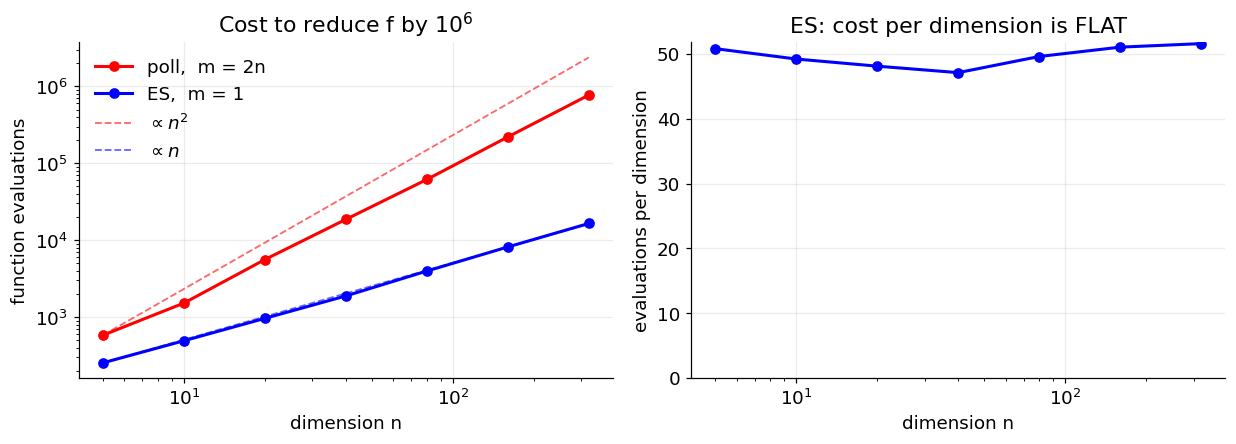

fitted log-log slopes:   poll = 1.75   ES = 1.01


In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.2))

# On a log-log plot a power law y ~ x^p is a STRAIGHT LINE of slope p.
a1.loglog(
    DIMS, poll_cost, "o-", lw=2, ms=6, color="red", label="poll,  m = 2n")

a1.loglog(
    DIMS,   es_cost, "o-", lw=2, ms=6, color="blue", label="ES,  m = 1")

ref = np.array([DIMS[0], DIMS[-1]])

a1.loglog(
    ref, poll_cost[0]*(ref/5)**2, "--", lw=1.2, color="red", alpha=.6, 
    label=r"$\propto n^2$")

a1.loglog(
    ref, es_cost[0]*(ref/5), "--", lw=1.2, color="blue", alpha=.6, 
    label=r"$\propto n$")

a1.set(xlabel="dimension n", ylabel="function evaluations",
       title="Cost to reduce f by $10^6$")
a1.legend()

a2.semilogx(
    DIMS, np.array(es_cost)/np.array(DIMS), "o-", lw=2, ms=6, color="blue")

a2.set(xlabel="dimension n", ylabel="evaluations per dimension", ylim=(0, None),
       title="ES: cost per dimension is FLAT")
plt.tight_layout(); plt.show()

print(f"fitted log-log slopes:   poll = {np.polyfit(np.log(DIMS), np.log(poll_cost), 1)[0]:.2f}"
      f"   ES = {np.polyfit(np.log(DIMS), np.log(es_cost), 1)[0]:.2f}")

The ES slope comes out at **1.01** — linear, to measurement precision. The polling
slope is about **1.7** and still
climbing toward its asymptotic value of 2 — our dimensions are not yet in the
asymptotic regime, and the sphere function is about as friendly as a problem gets, so
this is a *favorable* case for polling.

Two numbers to take away:

- the speed-up is **27× at $n = 160$** and still growing;
- the ES needs about **50 evaluations per dimension**, flat from $n = 5$ to $n = 320$.

***High dimension is not hopeless. It is hopeless for the *wrong algorithm*!**

---
## 3. Why the success rate is the right signal

The one non-obvious ingredient is the 1/5th rule. Why should the success *rate*
control the step size?

Because it is an **observable proxy for something you cannot see**. If $\sigma$ is far
too large, nearly every proposal overshoots and fails. If $\sigma$ is far too small,
nearly every proposal succeeds but achieves almost nothing. In between is a step size
matched to the local curvature. Rechenberg's calculation on the sphere model puts the
optimal success rate near $0.27$; the corridor model gives about $0.18$. One in five
is the compromise, and it is not worth tuning.

So the step size **tunes itself to the landscape**, rather than following a schedule
you guessed in advance.

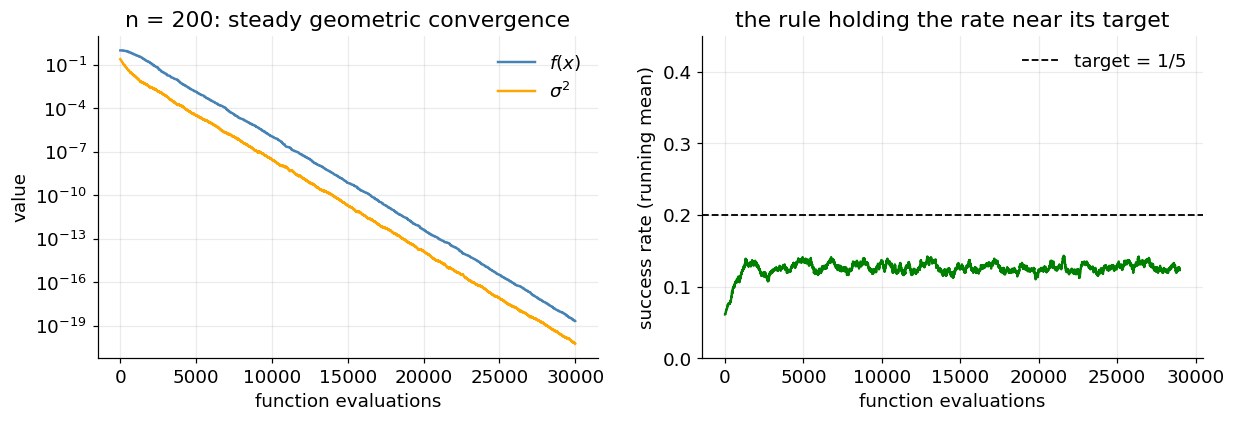

overall success rate = 0.124


In [9]:
h = es_1plus1(sphere_f, np.ones(200)/np.sqrt(200), sigma=0.5,
              max_nfev=30_000, seed=0)

# h is a list of (x, fx, sigma, nfev) tuples; pull out the three we plot
k  = np.array([e[3] for e in h])      # evaluation count
fv = np.array([e[1] for e in h])      # objective value
sg = np.array([e[2] for e in h])      # step size

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.0))
a1.semilogy(k, fv,    lw=1.6, color="steelblue", label="$f(x)$")
a1.semilogy(k, sg**2, lw=1.6, color="orange", label=r"$\sigma^2$")
a1.set(xlabel="function evaluations", ylabel="value",
       title="n = 200: steady geometric convergence")
a1.legend()

# Running average of the success rate. np.diff(fv) < 0 is True where f decreased;
# convolving with a box of width w averages it over w consecutive steps.
w = 1000
succ = np.convolve((np.diff(fv) < 0).astype(float), np.ones(w)/w, "valid")
a2.plot(k[1:len(succ)+1], succ, lw=1.5, color="green")
a2.axhline(0.2, ls="--", color="k", lw=1.2, label="target = 1/5")
a2.set(xlabel="function evaluations", ylabel="success rate (running mean)",
       ylim=(0, .45), title="the rule holding the rate near its target")
a2.legend(); plt.tight_layout(); plt.show()

print(f"overall success rate = {np.mean(np.diff(fv) < 0):.3f}")

### References for this notebook

- I. Rechenberg, *Evolutionsstrategie.* Frommann-Holzboog, Stuttgart, 1973 — the
  original (1+1)-ES and the 1/5th rule.
- H.-G. Beyer and H.-P. Schwefel, "Evolution strategies – A comprehensive
  introduction," *Natural Computing* **1**(1), 3–52 (2002).
  [doi:10.1023/A:1015059928466](https://doi.org/10.1023/A:1015059928466) — the
  accessible modern account, including the optimal success probabilities quoted above.
- L. N. Vicente, "Worst case complexity of direct search," *EURO Journal on
  Computational Optimization* **1**(1), 143–153 (2013).
  [doi:10.1007/s13675-012-0003-7](https://doi.org/10.1007/s13675-012-0003-7) — the
  $O(n^2\varepsilon^{-2})$ result.
- T. G. Kolda, R. M. Lewis and V. Torczon, "Optimization by Direct Search," *SIAM
  Review* **45**(3), 385–482 (2003).
  [doi:10.1137/S003614450242889](https://doi.org/10.1137/S003614450242889) — the
  standard survey of the polling family.
- N. Hansen, "The CMA Evolution Strategy: A Tutorial," arXiv:1604.00772 (2016).
  [arXiv:1604.00772](https://arxiv.org/abs/1604.00772) — the fix for Exercise 2.